# Daily water observations

USGS daily values are one statistic per day, usually the mean, computed from
the continuous record at each of its stream gages, wells, and water-quality
monitoring sites: streamflow, gage height, water temperature, and hundreds of
other parameters. The USGS publishes them through the Water Data OGC API;
a request returns CSV with one row per site, parameter, statistic, and day,
carrying its units, approval status, and qualifiers.

This walkthrough pulls water year 2024, 1 October 2023 to 30 September 2024,
of daily mean streamflow for the Arkansas River at Tulsa, Oklahoma. It needs
`usdata[pandas]` and matplotlib, downloads about 60 kB, and runs in a few
seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:07:36+00:00
usdata 0.26.0; pandas 3.0.6


## Select

The manifest names one site, one parameter, one statistic, and a window.
`07164500` is the gage's site number; `USGS-07164500` also works, and a
`bbox` or `place` selects every site inside it instead. `00060` is the
parameter code for discharge and `00003` the statistic code for the daily
mean, the default; codes are quoted so YAML keeps their leading zeros. Dates
are inclusive local calendar dates. The window is a USGS water year, which
runs October to September and is named for the year it ends in.

In [2]:
print(manifest.read_text())

name: tulsa-streamflow
sources:
  - dataset: usgs:water-daily
    start: 2023-10-01
    end: 2024-09-30
    variables: ["00060"]
    params:
      sites: "07164500"
      statistic_id: "00003"



## What arrives

The adapter pages through the API and downloads each page as raw CSV; one
water year at one site fits on a single page. The first pull writes
`dataset.lock.json` beside the manifest, pinning each file's checksum. The API
offers no immutable versions, so the lockfile and cache are the only record
of which values this analysis used.

In [3]:
result = pull(manifest)
print("Files:", len(result.fetched))
for item in result.fetched:
    print("File:", item.path.name)
    print("Bytes:", item.provenance.size)
    print("Source:", item.provenance.source_url)
    print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
    print("Checksum:", item.provenance.checksum)

Files: 1
File: daily_6e5b9ff3d15cda7ced8b.csv
Bytes: 60748
Source: https://api.waterdata.usgs.gov/ogcapi/v0/collections/daily/items?f=csv&time=2023-10-01%2F2024-09-30&statistic_id=00003&limit=10000&monitoring_location_id=USGS-07164500&parameter_code=00060&offset=0
Retrieved (UTC): 2026-09-24T06:07:37+00:00
Checksum: sha256:6b90b015313d14c9d7a142f3ea1616a21370f8132d09ac3676ad7dc0da5fc92b


## Open

The generic CSV reader returns a DataFrame with one row per day. `time` is
the local calendar date as text, `value` the daily mean, and
`unit_of_measure` its unit, cubic feet per second: the API has no metric
option. `x` and `y` are the site's longitude and latitude. `approval_status`
says whether the USGS has reviewed a value, `qualifier` flags values such as
estimates, and `last_modified` records when each row last changed. Rows do
not arrive in date order, so sort after parsing `time`. A day without a value
has no row at all, so compare against the full calendar to find gaps.

In [4]:
frame = pd.concat([item.open() for item in result.fetched], ignore_index=True)
frame["time"] = pd.to_datetime(frame["time"])
frame = frame.sort_values("time", ignore_index=True)
print(f"{len(frame)} rows, {frame['time'].min():%Y-%m-%d} to {frame['time'].max():%Y-%m-%d}")
missing = pd.date_range("2023-10-01", "2024-09-30").difference(frame["time"])
print("Days with no row:", missing.strftime("%Y-%m-%d").tolist())
print(
    "Site:", frame["monitoring_location_id"].iloc[0], "at", frame["y"].iloc[0], frame["x"].iloc[0]
)
print("Units:", frame["unit_of_measure"].unique().tolist())
print("Approval:", frame["approval_status"].value_counts().to_dict())
print("Qualifier:", frame["qualifier"].value_counts(dropna=False).to_dict())
print("Last modified:", frame["last_modified"].str[:10].value_counts().to_dict())
frame[["time", "value", "unit_of_measure", "approval_status", "qualifier"]].head()

365 rows, 2023-10-01 to 2024-09-29
Days with no row: ['2024-09-30']
Site: USGS-07164500 at 36.140648067526 -96.0063865713339
Units: ['ft^3/s']
Approval: {'Approved': 365}
Qualifier: {nan: 190, "['ESTIMATED']": 175}
Last modified: {'2025-05-01': 342, '2025-08-01': 23}


,time,value,unit_of_measure,approval_status,qualifier
0,2023-10-01,297.0,ft^3/s,Approved,NaN
1,2023-10-02,719.0,ft^3/s,Approved,['ESTIMATED']
2,2023-10-03,480.0,ft^3/s,Approved,['ESTIMATED']
3,2023-10-04,2240.0,ft^3/s,Approved,NaN
4,2023-10-05,1480.0,ft^3/s,Approved,NaN


## A first look

A water year of daily mean flow on a logarithmic axis, with the days the USGS
qualifies as estimated marked.

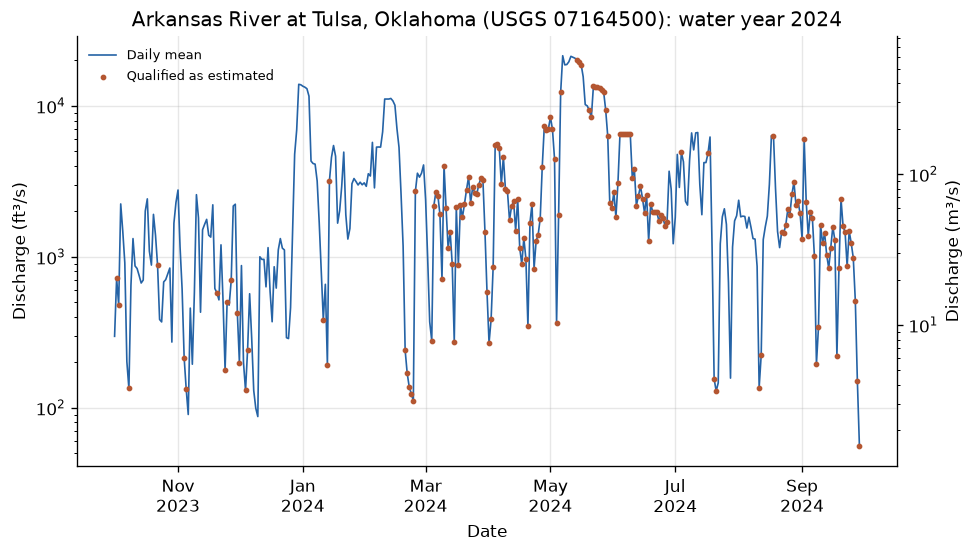

In [5]:
CUBIC_METRES_PER_CUBIC_FOOT = 0.0283168
estimated = frame["qualifier"].fillna("").str.contains("ESTIMATED")

fig, ax = plt.subplots(layout="constrained")
ax.plot(frame["time"], frame["value"], color="#2563a6", linewidth=1, label="Daily mean")
ax.scatter(
    frame.loc[estimated, "time"],
    frame.loc[estimated, "value"],
    color="#b45631",
    s=6,
    zorder=3,
    label="Qualified as estimated",
)
ax.set_yscale("log")
ax.set_ylabel("Discharge (ft³/s)")
metric = ax.secondary_yaxis(
    "right",
    functions=(
        lambda cfs: cfs * CUBIC_METRES_PER_CUBIC_FOOT,
        lambda cms: cms / CUBIC_METRES_PER_CUBIC_FOOT,
    ),
)
metric.set_ylabel("Discharge (m³/s)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_xlabel("Date")
ax.set_title("Arkansas River at Tulsa, Oklahoma (USGS 07164500): water year 2024")
ax.legend(loc="upper left", fontsize=8, frameon=False)
plt.show()

In [6]:
peak = frame.loc[frame["value"].idxmax()]
low = frame.loc[frame["value"].idxmin()]
monthly = frame.groupby(frame["time"].dt.to_period("M"))["value"].mean()
print(f"Peak daily mean: {peak['value']:,.0f} ft³/s on {peak['time']:%Y-%m-%d}")
print(f"Lowest daily mean: {low['value']:,.1f} ft³/s on {low['time']:%Y-%m-%d}")
print(f"Ratio of highest to lowest: {peak['value'] / low['value']:,.0f}")
print(f"Median daily mean: {frame['value'].median():,.0f} ft³/s")
print(
    f"May 2024 mean: {monthly['2024-05']:,.0f} ft³/s; water-year mean: {frame['value'].mean():,.0f}"
)
print(f"Days qualified as estimated: {int(estimated.sum())} of {len(frame)}")

Peak daily mean: 21,500 ft³/s on 2024-05-07
Lowest daily mean: 55.6 ft³/s on 2024-09-29
Ratio of highest to lowest: 387
Median daily mean: 1,860 ft³/s
May 2024 mean: 12,470 ft³/s; water-year mean: 3,291
Days qualified as estimated: 175 of 365


Daily flow at Tulsa spanned a factor of almost 400 in one year, around a
median near 1,900 ft³/s. The gage is downstream of Keystone Dam, and the
record looks managed as much as natural: flat-topped stretches near
14,000 ft³/s in late December and near 20,000 ft³/s for two weeks after the
early-May storms, and one-day drops to a few hundred ft³/s, fit a reservoir's
release schedule better than rainfall alone. Almost half the year's values
are qualified as estimated although every row is approved, which matters to
anyone reading "approved" as "measured".

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. The USGS
revises daily values, as `last_modified` shows, so keep the cache with the
manifest and lockfile. `usdata cite dataset.yaml` prints the same citation.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

usgs:water-daily
  U.S. Geological Survey, Water Data for the Nation daily values, accessed via usdata
  homepage: https://api.waterdata.usgs.gov/
  license: US Government Work (public domain)
  terms: https://www.usgs.gov/information-policies-and-instructions/copyrights-and-credits
  retrieved: 2026-09-24; 1 checksummed asset (60,748 bytes) pinned by usdata 0.26.0
  sources: 1


## What was awkward

- Rows arrive out of date order, so a line plot of the raw frame zigzags
  until it is sorted on a parsed `time`.
- `qualifier` is a Python-style list written as text, such as
  `['ESTIMATED']`, so filtering on it means string matching or parsing.
- `approval_status` and `qualifier` are separate: an approved value can
  still be an estimate, and nothing in the column names says so.
- Discharge comes only in cubic feet per second; there is no request option
  for metric units, so the conversion is the reader's job.
- The site number and the monitoring location ID differ by the `USGS-`
  prefix; the manifest accepts either, but joining against other tables
  needs one form chosen deliberately.
- The API has no versioned snapshots. `last_modified` shows rows changing
  months after the water year ended, so the same request can return
  different bytes later.
- Water year 2024 has 366 days but returned 365 rows: 30 September 2024 has
  no value, and the API leaves the day out rather than returning an empty
  one. The gap is easy to miss unless the dates are checked against a
  calendar.